In [5]:
!git clone https://{token}@github.com/{username}/{repo}

Cloning into 'Case-Exercises-1'...
remote: Enumerating objects: 3, done.
remote: Counting objects: 100% (3/3), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 3 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (3/3), done.


In [42]:
%ls

README.md  well_depths.csv


In [48]:
!git status

On branch main
Your branch is ahead of 'origin/main' by 1 commit.
  (use "git push" to publish your local commits)

nothing to commit, working tree clean


In [38]:
%cd /content/Case-Exercises-1

/content/Case-Exercises-1


In [25]:
!mv /content/well_depths.csv /content/Case-Exercises-1

In [47]:
!git add --all

In [46]:
!git commit -m "Case Exercise 1: Usan Reservoir Temperature Calculator"

[main d18f043] Case Exercise 1: Usan Reservoir Temperature Calculator
 1 file changed, 51 insertions(+)
 create mode 100644 well_depths.csv


In [50]:
!git push origin main

Enumerating objects: 4, done.
Counting objects: 100% (4/4), done.
Delta compression using up to 2 threads
Compressing objects: 100% (3/3), done.
Writing objects: 100% (3/3), 775 bytes | 775.00 KiB/s, done.
Total 3 (delta 0), reused 0 (delta 0), pack-reused 0
To https://github.com/Hassanat718/Case-Exercises-1
   446a067..d18f043  main -> main


# **QUESTION 1**
Write a function reservoir_temperature(depth_m, surface_temp=4.0, gradient=30.0) that returns temperature in °C. Include docstring, type hints, and input validation.

In [13]:
def reservoir_temperature(
    depth_m: float,
    surface_temp: float = 4.0,
    gradient: float = 30.0
) -> float:
    """
    Calculate reservoir temperature from well depth.
    """

    # Check that the depth is a number
    if not isinstance(depth_m, (int, float)):
        raise TypeError("Depth must be a numeric value.")

    # Check that the depth is not negative
    if depth_m < 0:
        raise ValueError("Depth cannot be negative.")

    # Calculate and return the reservoir temperature
    # Divide depth by 1000 to convert metres to kilometres
    return surface_temp + (gradient * depth_m / 1000)

In [10]:
reservoir_temperature(2000)

64.0

In [11]:
reservoir_temperature(-1000)

ValueError: Depth cannot be negative.

In [12]:
reservoir_temperature(1000)

34.0

# **QUESTION 2**
Read a CSV file (well_depths.csv) containing 50 well depth measurements and calculate temperatures for all wells using your function.

In [14]:
import pandas as pd #importing panda

In [15]:
df = pd.read_csv("/content/well_depths.csv") # Read the CSV file
df.head() #to show the first 5 rows of the CSV.

,well_id,depth_m,temperature_c
0,1,850,29.50
1,2,1025,34.75
2,3,1190,39.70
3,4,1375,45.25
4,5,1540,50.20


In [19]:
# Calculate temperature for each well depth using the reservoir_temperature function
df["temperature_C"] = df["depth_m"].apply(reservoir_temperature)
df.head()

,well_id,depth_m,temperature_c,temperature_C
0,1,850,29.50,29.50
1,2,1025,34.75,34.75
2,3,1190,39.70,39.70
3,4,1375,45.25,45.25
4,5,1540,50.20,50.20


# **QUESTION 3**

Create a scatter plot showing temperature vs. depth with a linear trendline. Label axes with units, add a title, and include the trendline equation in the legend.    

In [20]:
import matplotlib.pyplot as plt
import numpy as np

In [21]:
# Get the depth and temperature data
x = df["depth_m"]
y = df["temperature_C"]

# Calculate the slope and intercept of the trendline
slope, intercept = np.polyfit(x, y, 1)

# Calculate the temperature values predicted by the trendline
trendline = slope * x + intercept

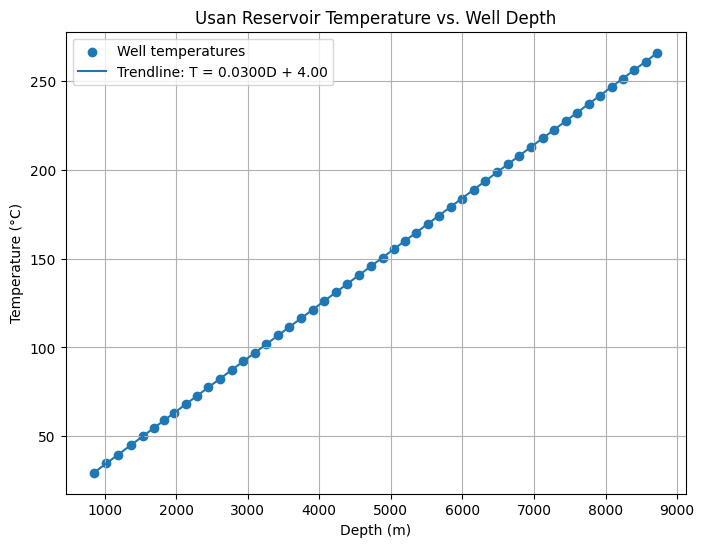

In [23]:
# Create the scatter plot
plt.figure(figsize=(8, 6))

# Plot the actual well temperatures
plt.scatter(x, y, label="Well temperatures")

# Plot the linear trendline
plt.plot(
    x,
    trendline,
    label=f"Trendline: T = {slope:.4f}D + {intercept:.2f}"
)

# Add labels and title
plt.xlabel("Depth (m)")
plt.ylabel("Temperature (°C)")
plt.title("Usan Reservoir Temperature vs. Well Depth")

# Show the legend
plt.legend()

# Show grid lines
plt.grid(True)

# Display the plot
plt.show()

#**QUESTION 4**
Add error handling for negative depths and non-numeric inputs. Write at least 3 test cases that verify correct behaviour for both valid and invalid inputs.    

In [24]:
# Test 1: Valid depth
assert reservoir_temperature(1000) == 34.0

# Test 2: Negative depth should raise a ValueError
try:
    reservoir_temperature(-500)
except ValueError:
    print("Test 2 passed: Negative depth was rejected.")

# Test 3: Non-numeric depth should raise a TypeError
try:
    reservoir_temperature("1000")
except TypeError:
    print("Test 3 passed: Non-numeric input was rejected.")

Test 2 passed: Negative depth was rejected.
Test 3 passed: Non-numeric input was rejected.
